# Principal Component Analysis (PCA)

This notebook presents a complete **Principal Component Analysis (PCA)** workflow using `bluemath_tk`: data preparation, model fitting, dimensionality reduction, reconstruction, diagnostics, persistence, and visualization of the Empirical Orthogonal Functions (EOFs).

> **Objective:** summarize a multidimensional dataset with a small number of components while retaining as much of its original variability as possible.

## Workflow

1. Load a sample `xarray.Dataset`.
2. Configure and fit the PCA model.
3. Transform the original fields into principal-component scores.
4. Reconstruct the dataset and inspect the model diagnostics.
5. Save the fitted model and plot its leading EOFs.

In [1]:
import pandas as pd

from bluemath_tk.core.data.sample_data import get_2d_dataset
from bluemath_tk.datamining.pca import PCA

## 1. Load the sample dataset

The helper function returns an `xarray.Dataset` containing the variables `X` and `Y`. Inspecting the dataset first is useful for confirming its variables, coordinates, dimensions, and missing values before stacking it for PCA.

In [2]:
ds = get_2d_dataset()
ds

<xarray.Dataset> Size: 314kB
Dimensions:  (coord1: 20, coord2: 20, coord3: 49)
Coordinates:
  * coord1   (coord1) float64 160B -100.0 -89.47 -78.95 ... 78.95 89.47 100.0
  * coord2   (coord2) float64 160B -100.0 -89.47 -78.95 ... 78.95 89.47 100.0
  * coord3   (coord3) int64 392B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49
Data variables:
    X        (coord1, coord2, coord3) float64 157kB -0.08724 0.2777 ... -0.2849
    Y        (coord1, coord2, coord3) float64 157kB 0.08713 -0.2742 ... 0.2811

## 2. Configure the PCA model

PCA rotates the original feature space onto orthogonal directions of decreasing variance. If $\mathbf{X}$ is the centered data matrix, PCA decomposes it as

$$\mathbf{X} \approx \mathbf{P}\mathbf{E}^{T},$$

where $\mathbf{P}$ contains the principal-component scores and $\mathbf{E}$ contains the EOFs (spatial patterns or loadings).

The model retains five components. Standard PCA is used instead of incremental PCA, and debug logging is enabled to expose additional execution details.

### Constructor arguments

- `n_components`: amount of information retained. An integer such as `5` keeps exactly five components; a float can instead represent a desired cumulative explained-variance ratio.
- `is_incremental`: selects standard PCA (`False`) or incremental PCA (`True`). Incremental fitting is useful when the complete matrix is too large to process in memory at once.
- `debug`: enables more detailed diagnostic logging. It is helpful while learning or troubleshooting, but can be disabled for quieter production runs.

In [3]:
pca = PCA(
    n_components=5,
    is_incremental=False,
    debug=True,
)

## 3. Fit the model

The variables `X` and `Y` are combined into the feature matrix by stacking `coord1` and `coord2`; `coord3` defines the observations placed along the PCA row dimension.

The optional preprocessing settings demonstrate how to handle realistic data:

- `windows_in_pca_dim_for_rows` restricts `X` to the selected windows `[1, 2, 3]`.
- `value_to_replace_nans` replaces remaining missing values in `X` with `0.0`.
### Arguments used in `fit`

- `data`: input `xarray.Dataset` used to learn the PCA basis.
- `vars_to_stack`: dataset variables combined into one feature matrix. Here PCA learns the joint variability of `X` and `Y`.
- `coords_to_stack`: coordinates flattened into feature columns. In this example, every `coord1`–`coord2` location becomes a PCA feature.
- `pca_dim_for_rows`: dimension kept as observations or rows, commonly time. Here every `coord3` value becomes one observation.
- `windows_in_pca_dim_for_rows`: lag or rolling-window steps added for each variable. `X: [1, 2, 3]` incorporates three shifted versions of `X`. Use `{}` when no temporal windows are needed.
- `value_to_replace_nans`: replacement value per variable after preprocessing. `X: 0.0` fills remaining missing values in `X` with zero.
- `nan_threshold_to_drop`: valid-data threshold applied per variable. The value `0.95` requires approximately 95% valid values; features that do not meet it are excluded.
- `scale_data`: defaults to `True` and standardizes features so variables with larger units do not dominate the components. It is omitted here because the default is appropriate.

`fit` learns the EOFs and preprocessing metadata in place; it does not return the transformed PCs.

In [4]:
pca.fit(
    data=ds,
    vars_to_stack=["X", "Y"],
    coords_to_stack=["coord1", "coord2"],
    pca_dim_for_rows="coord3",
    windows_in_pca_dim_for_rows={"X": [1, 2, 3]},
    value_to_replace_nans={"X": 0.0},
    nan_threshold_to_drop={"X": 0.95},
)

2026-08-07 12:18:44,551 - PCA - WARNING - Using 400 out of 400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-08-07 12:18:44,551 - PCA - WARNING - Using 400 out of 400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-08-07 12:18:44,552 - PCA - WARNING - Using 400 out of 400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-08-07 12:18:44,552 - PCA - WARNING - Data contains NaNs.
2026-08-07 12:18:44,553 - PCA - WARNING - Using 400 out of 400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-08-07 12:18:44,554 - PCA - WARNING - Data contains NaNs.
2026-08-07 12:18:44,555 - PCA - WARNING - Using 0 out of 400 available variables 
If this is originated by using few times, plea

## 4. Transform and reconstruct the data

`transform(data=ds)` receives a dataset with the same variables and coordinate structure used during fitting and returns its principal-component scores. It uses the preprocessing configuration already stored in `pca`.

`inverse_transform(PCs=pcs)` receives those component scores through the case-sensitive `PCs` argument and maps them back to an `xarray.Dataset` in the original variable space. Because only five components are retained, the reconstruction is a compressed approximation rather than an exact copy.

In [5]:
pcs = pca.transform(data=ds)
pcs

2026-08-07 12:18:44,589 - PCA - WARNING - Using 400 out of 400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-08-07 12:18:44,590 - PCA - WARNING - Using 400 out of 400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-08-07 12:18:44,591 - PCA - WARNING - Using 400 out of 400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-08-07 12:18:44,592 - PCA - WARNING - Data contains NaNs.
2026-08-07 12:18:44,593 - PCA - WARNING - Using 400 out of 400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-08-07 12:18:44,594 - PCA - WARNING - Data contains NaNs.
2026-08-07 12:18:44,595 - PCA - WARNING - Using 0 out of 400 available variables 
If this is originated by using few times, plea

<xarray.Dataset> Size: 2kB
Dimensions:      (coord3: 49, n_component: 5)
Coordinates:
  * coord3       (coord3) int64 392B 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
  * n_component  (n_component) int64 40B 0 1 2 3 4
Data variables:
    PCs          (coord3, n_component) float64 2kB -10.44 25.48 ... 20.8 1.378
    stds         (n_component) float64 40B 23.47 19.81 16.57 13.96 13.16

In [6]:
reconstructed_ds = pca.inverse_transform(PCs=pcs)
reconstructed_ds

<xarray.Dataset> Size: 785kB
Dimensions:  (coord3: 49, coord1: 20, coord2: 20)
Coordinates:
  * coord3   (coord3) int64 392B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49
  * coord1   (coord1) float64 160B -100.0 -89.47 -78.95 ... 78.95 89.47 100.0
  * coord2   (coord2) float64 160B -100.0 -89.47 -78.95 ... 78.95 89.47 100.0
Data variables:
    X        (coord3, coord1, coord2) float64 157kB -0.0713 -0.2654 ... -0.2426
    Y        (coord3, coord1, coord2) float64 157kB 0.06605 0.2611 ... 0.2314
    X_1      (coord3, coord1, coord2) float64 157kB 0.1585 0.1327 ... 0.671
    X_2      (coord3, coord1, coord2) float64 157kB 0.1196 0.1238 ... -0.3274
    X_3      (coord3, coord1, coord2) float64 157kB nan nan nan ... nan nan nan

## 5. Inspect EOFs and explained variance

The main PCA diagnostics are:

- **EOFs:** orthogonal patterns that define the new coordinate system.
- **Explained variance:** variance represented by each component.
- **Explained-variance ratio:** fraction of total variance represented by each component.
- **Cumulative ratio:** total fraction retained by the first $k$ components.

A rapid plateau in the cumulative ratio indicates that a compact model captures most of the information.

In [7]:
eofs = pca.eofs
explained_variance = pca.explained_variance
explained_variance_ratio = pca.explained_variance_ratio
cumulative_explained_variance_ratio = (
    pca.cumulative_explained_variance_ratio
)

variance_summary = pd.DataFrame(
    {
        "Explained variance": explained_variance,
        "Explained variance ratio": explained_variance_ratio,
        "Cumulative ratio": cumulative_explained_variance_ratio,
    },
    index=[f"PC{i}" for i in range(1, len(explained_variance) + 1)],
)
variance_summary.style.format("{:.4f}").set_caption(
    "Variance retained by each principal component"
)

,Explained variance,Explained variance ratio,Cumulative ratio
PC1,562.3095,0.3443,0.3443
PC2,400.5751,0.2453,0.5895
PC3,280.4055,0.1717,0.7612
PC4,199.0373,0.1219,0.8831
PC5,176.7557,0.1082,0.9913


## 6. Save the fitted model

The complete fitted PCA object is serialized to a pickle file. This preserves the preprocessing metadata, EOFs, and fitted transformation so the same model can be reused later without fitting it again.

`save_model(path)` receives the destination filename. Here `pca_model.pkl` is created in the notebook's working directory and stores the complete fitted object, including preprocessing metadata and EOFs.

> Only load pickle files from trusted sources, because unpickling arbitrary files can execute code.

In [8]:
pca.save_model("pca_model.pkl")

## 7. Plot the leading EOFs

The first three EOFs are displayed for `X` and `Y`. These plots show the dominant patterns of variability learned from the dataset. The sign of an EOF is arbitrary; its spatial structure and its pairing with the corresponding principal-component score are what carry meaning.

- `vars_to_plot`: variables from the fitted dataset whose EOF patterns should be drawn.
- `num_eofs`: number of leading EOFs to display. The first three are used because they explain the largest successive fractions of variance.

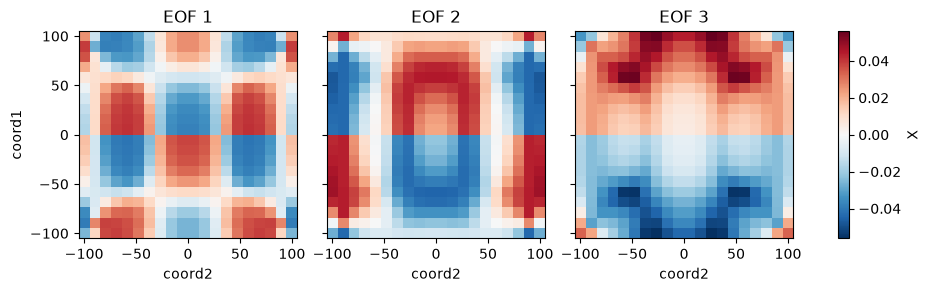

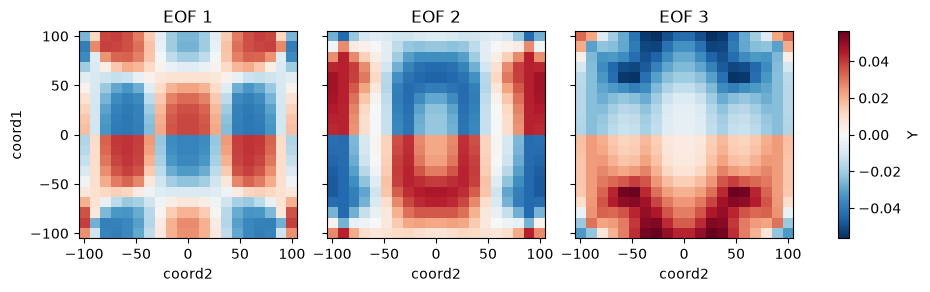

In [9]:
pca.plot_eofs(vars_to_plot=["X", "Y"], num_eofs=3)

## Summary

The fitted model compresses the joint variability of `X` and `Y` into five components. The explained-variance diagnostics quantify the information retained, the inverse transformation reconstructs the original fields, and the EOF plots help interpret the dominant patterns.